This code reads frequency tables of interactions between Alpha Carbon of Asp25 and atoms within 5A,
and returns a graph with CA_Asp25 in the center and CA of interacting residues, where frequency is non-zero.

In [1]:
#Install necessary libraries
!pip install igraph
!pip install pycairo

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#IMPORT
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig
from plotly.colors import n_colors
import numpy as np
import matplotlib.patches as mpatches


In [4]:
#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Manips/Tables/'
os.chdir(rootdir)

In [5]:
#MAIN

# 1. Read data

# 1.0. Setup
df_list = []
CA_atoms = []
residue_dico = {}
residue_identifier_set_all_sims = set()

# 1.1. Open frequency tables, read as df
freq_df_paths = ["V1_ASP_env_atoms_frequency.csv",
                "V11_ASP_env_atoms_frequency.csv",
                "V12_ASP_env_atoms_frequency.csv",
                "V7_ASP_env_atoms_frequency.csv",
                "V8_ASP_env_atoms_frequency.csv",
                "V21_ASP_env_atoms_frequency.csv"]
for sim in freq_df_paths:
    sim_name = sim.replace("_ASP_env_atoms_frequency.csv", "")
    df_sim = pd.read_csv(sim)
    
    # 1.2. Filter only alpha carbons (and that are not Asp25 alpha carbon)
    filtered_CA = df_sim[
        df_sim["Residue"].apply(lambda x: 'CA' in x and 'ASP_25' not in x)
        ].copy()

    # 1.3. Save to new df for graph parameters
    df_new = pd.DataFrame()
    df_new["Source"] = filtered_CA["Residue"]
    df_new["Target"] = "CA_Asp25_chB"
    df_new["Weight"] = filtered_CA['Frequency'].apply(lambda x: int(x))
    
    # 1.3.1. For each CA, get their residue_id and chain
    chain_label_list = []
    res_id_list = []
    for CA in filtered_CA["Residue"].values:
        res_str = CA.split('_')
        atom_id = int(res_str[0])
        res_id = '_'.join(res_str[2:])
        if atom_id < 1536:
            chain_label_list.append("Chain A")
        else:
            chain_label_list.append("Chain B")
        res_id_list.append(res_id)
        # Collect all unique residues in a set
        residue_identifier_set_all_sims.add(res_id)
    df_new["Chain"] = chain_label_list
    df_new["Residue_Id"] = res_id_list
    
    df_list.append((sim_name, df_new))

# 1.4. Make color dict for coloring the CA atoms
residue_id_color_dico = {}
for i, res_id in enumerate(sorted(list(residue_identifier_set_all_sims))):
    np.random.seed(i) # set seed for reproducibility of colors
    color = tuple(np.random.choice(range(256), size=3) / 255.0)
    residue_id_color_dico[res_id] = color

/tmp/ipykernel_10431/4029976209.py:102: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_handles.append(mpatches.Patch(color=chain_colors["Chain A"], label='Chain A Group', edgecolor='black', linewidth=0.5))
/tmp/ipykernel_10431/4029976209.py:104: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_handles.append(mpatches.Patch(color=chain_colors["Chain B"], label='Chain B Group', edgecolor='black', linewidth=0.5))


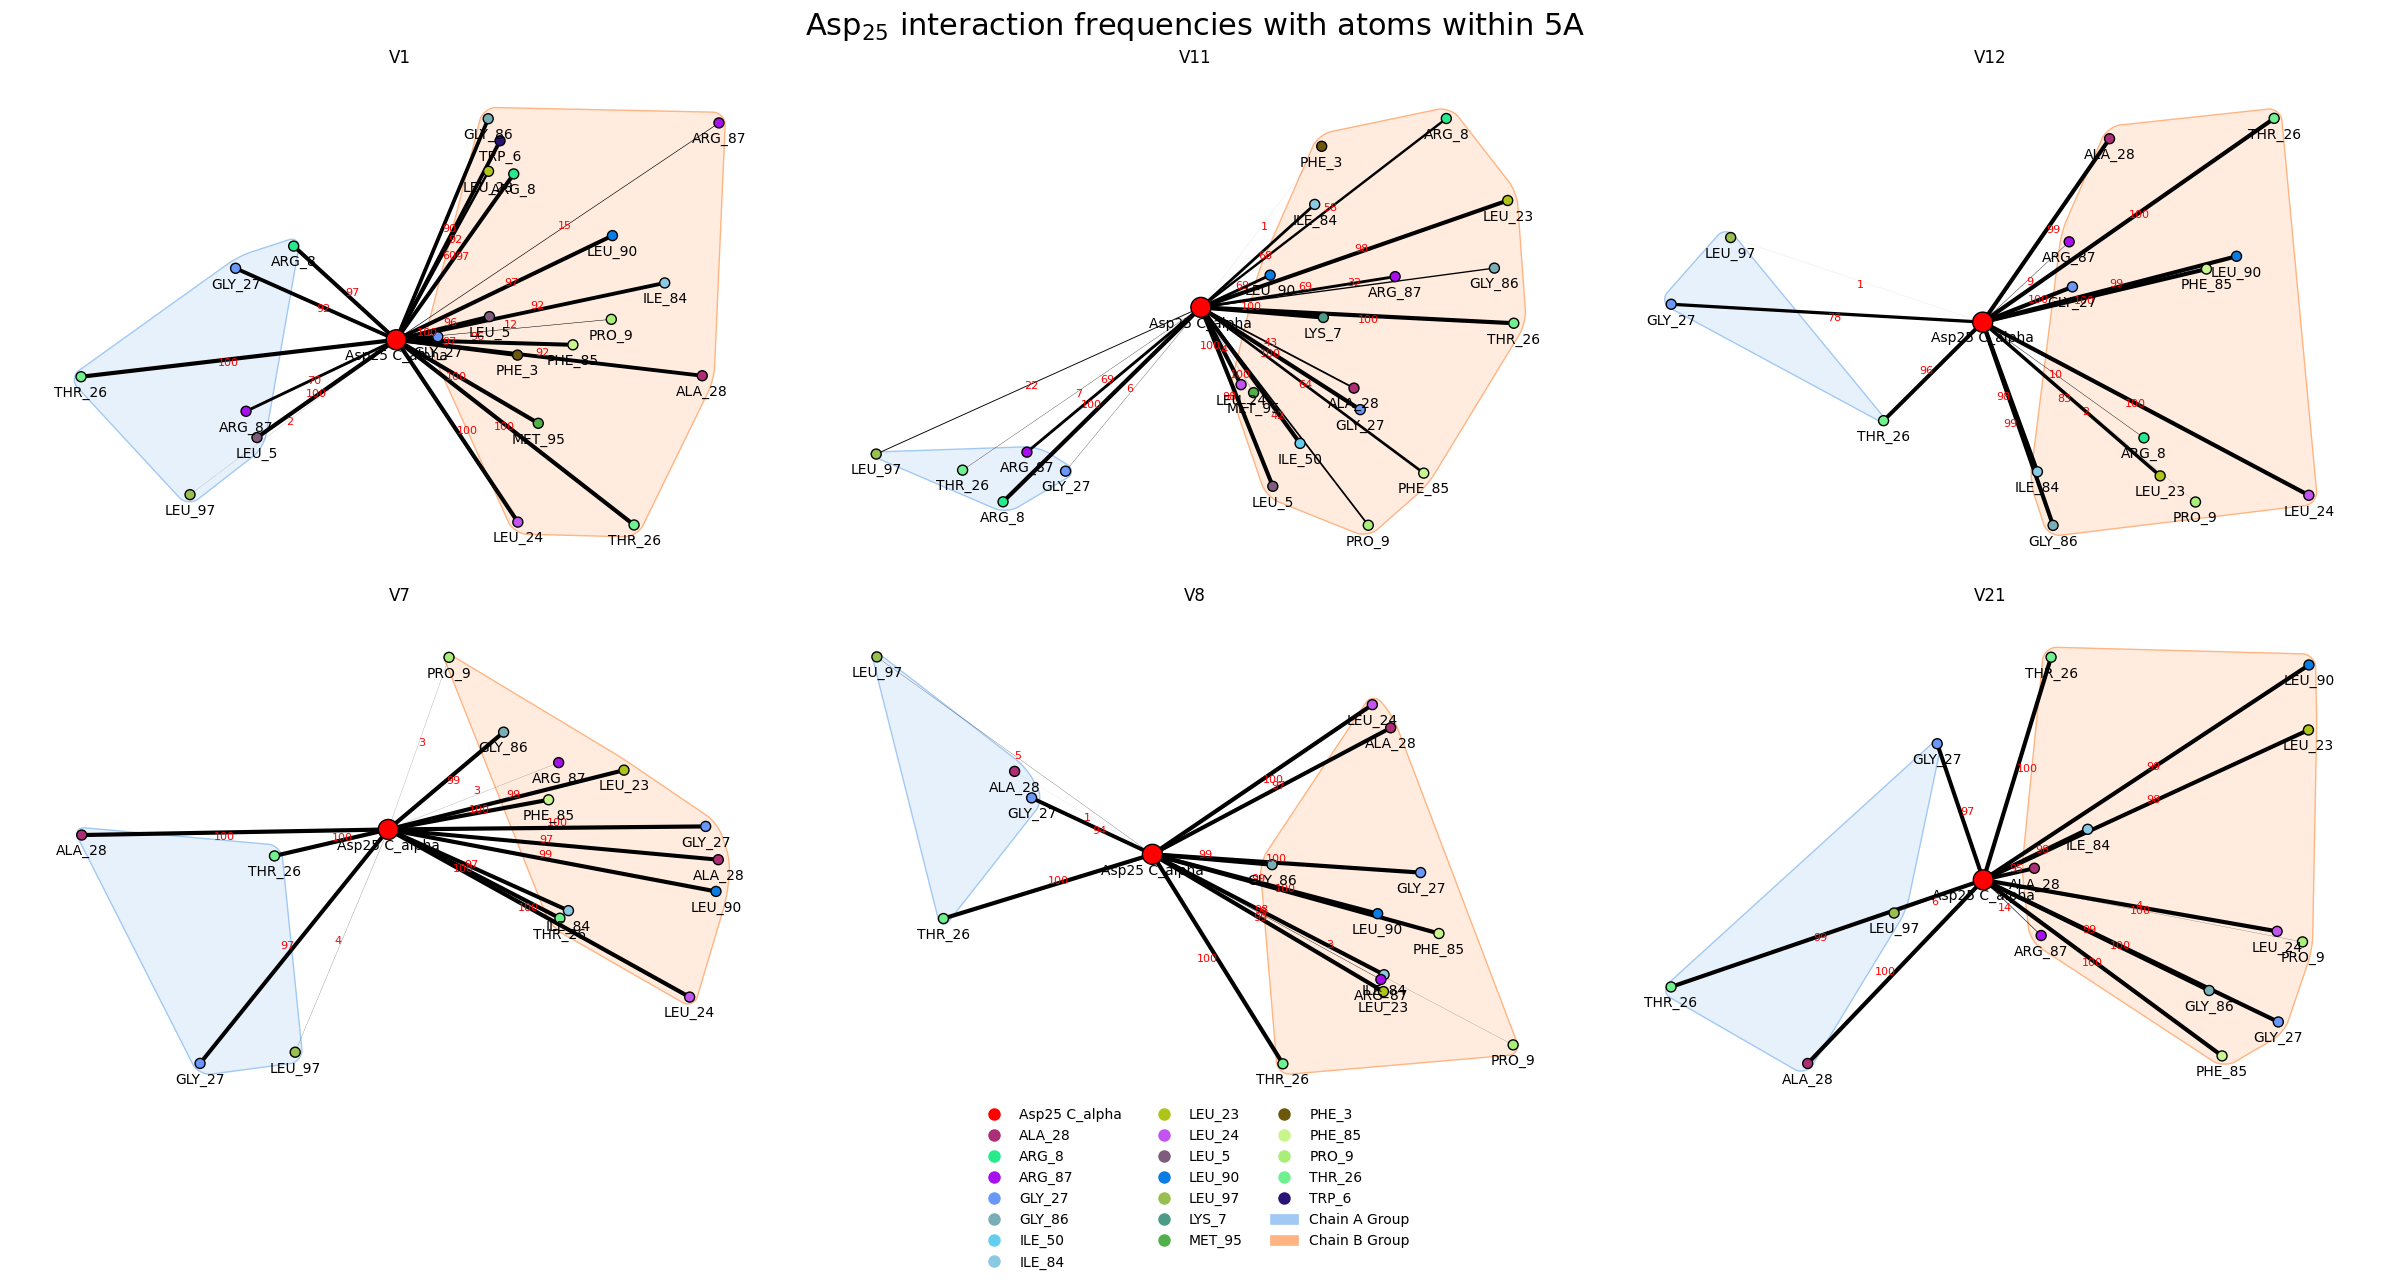

In [10]:
# 2. Create graph

# 2.1. Set colours for chain marking
chain_colors = {"Chain A": "#a1c9f4", "Chain B": "#ffb482"} 

# 2.2. Set figure parameters
num_simulations = len(df_list)
num_cols_plot = 3
num_rows_plot = (num_simulations + num_cols_plot - 1) // num_cols_plot
fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(num_cols_plot * 8, num_rows_plot * 6), squeeze=False)
axes = axes.flatten()

# 2.3. Create figure title
fig.suptitle("Asp$_{25}$ interaction frequencies with atoms within 5A", fontsize=22)

# 2.4. Plot for each simulation
for plot_idx, ((sim_name, sim), ax) in enumerate(zip(df_list, axes)):
    ax.set_title(sim_name)
    g = ig.Graph.DataFrame(sim, directed=False, use_vids=False)

    # 2.4.1. Add chain and residue_id as vertex attributes to the graph
    chain_map = sim.set_index('Source')['Chain'].to_dict()
    res_id_map = sim.set_index('Source')['Residue_Id'].to_dict()

    # 2.4.2. Select Asp_25 as central atom, 
    for v_idx in range(len(g.vs)):
        v_name = g.vs[v_idx]['name']
        if v_name == "CA_Asp25_chB":
            g.vs[v_idx]['chain'] = 'Chain B'
            g.vs[v_idx]['residue_identifier'] = 'ASP_25'
        else:
            g.vs[v_idx]['chain'] = chain_map.get(v_name)
            g.vs[v_idx]['residue_identifier'] = res_id_map.get(v_name)
    
    # 2.4.3. Set graph parameters (vertices, edges, labels, colors, sizes, coordinates for layout)
    vertices = g.vs
    colors = []
    labels = []
    sizes = []
    group_A_indices = []
    group_B_indices = []
    custom_layout = []

    for i, v in enumerate(vertices):
        if v['name'] == "CA_Asp25_chB":
            colors.append((1.0, 0.0, 0.0)) # make CA_asp25 atom red
            labels.append("\n\n"+"Asp25 C_alpha")
            sizes.append(20)
            custom_layout.append([0.0, 0.0]) # CA_asp25 to center
        else:
            color = residue_id_color_dico.get(v['residue_identifier'], (0.5, 0.5, 0.5))
            colors.append(color)
            labels.append("\n\n"+v['residue_identifier'])
            sizes.append(10)
            # 2.4.3.1. Make chain A residues appear on the left (random negative x), and chain B on the right (positive x)
            if v['chain'] == "Chain A":
                group_A_indices.append(i)
                custom_layout.append([np.random.uniform(-0.9, -0.1), np.random.uniform(-0.7, 0.7)])
            elif v['chain'] == "Chain B":
                group_B_indices.append(i)
                custom_layout.append([np.random.uniform(0.1, 0.9), np.random.uniform(-0.7, 0.7)])
            else: # if chain not indicated, place around center
                custom_layout.append([np.random.uniform(-0.1, 0.1), np.random.uniform(-0.1, 0.1)]) # Place around center
    # 2.4.3.2. Select weights to appear (if 0, not draw a line)
    weights = [w for w in g.es['Weight'] if w>0]
    # 2.4.3.3. Make weight lines thinner
    edge_widths = [(w/50)*1.5 for w in weights] 
# 2.4.4. Plot
    ig.plot(g, target=ax,
            vertex_size=sizes,
            vertex_color=colors,
            vertex_label=labels,
            vertex_label_size=10,
            edge_width=edge_widths,
            edge_curved=0,
            edge_label=weights,
            edge_label_size=8,
            edge_color='black',
            edge_label_color="red",
            layout=custom_layout,
            bbox=(400, 400),
            mark_groups=[(group_A_indices, chain_colors["Chain A"]),
                        (group_B_indices, chain_colors["Chain B"])],
            margin=20)

# 2.4.5. Create legend handles and labels list 
legend_handles = []
legend_labels = []

# 2.4.6. Central atom label definition
legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label='CA_Asp25',
                                markerfacecolor=(1.0, 0.0, 0.0), markersize=10))
legend_labels.append('Asp25 C_alpha')

# 2.4.7. Interacting atoms label definition
for res_id, color in sorted(residue_id_color_dico.items()):
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=res_id,
                                    markerfacecolor=color, markersize=10))
    legend_labels.append(res_id)

# 2.4.8. Colored rectangles in legend for chain A and chain B mark groups
legend_handles.append(mpatches.Patch(color=chain_colors["Chain A"], label='Chain A Group', edgecolor='black', linewidth=0.5))
legend_labels.append('Chain A Group')
legend_handles.append(mpatches.Patch(color=chain_colors["Chain B"], label='Chain B Group', edgecolor='black', linewidth=0.5))
legend_labels.append('Chain B Group')

# 2.4.9. Add legend below figure
fig.legend(handles=legend_handles, labels=legend_labels,
        loc='lower center', ncol=3, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# 2.5. Save figure
fig.savefig("../Figures/Env25_graph")